# YHP Credit Assessment — Part 2b: Predicting `loss_amount`

## Scenario: Regression

This notebook builds regression models to predict **how much** a loan loses,
given that it lost something. It is the regression counterpart to the `is_loss`
classifier in `yhp_credit_classification.ipynb`.

The two together give the quantity a lender actually wants:

```
expected loss per loan  =  P(loss)          ×  E[loss | loss]
                           classifier          this notebook
```

The workflow follows the airplane crash fatalities methodology: data
understanding, a check on target skew, `Pipeline` and `ColumnTransformer`
preprocessing fitted after the split, five regression models compared on the
same held-out set, then residual and coefficient analysis of the winner.

## Objective and model selection

### Why a separate population from the classifier

The classifier predicts **whether** a loan loses money, across all 10,000 loans.
This notebook predicts **how much**, across the 2,232 loans that lost something.

Modelling `loss_amount` over all 10,000 loans would make **75.67% of the target
exactly zero**. A linear model fitted on that predicts close to zero nearly
everywhere, and its R² is driven by how well it reproduces the zeros rather than
by anything about severity. Splitting the problem into frequency and severity is
the standard credit-risk decomposition, and it is what makes each half
answerable.

Note that this population is **not** the classifier's positive class. 2,232
loans have a positive loss amount, 2,119 carry the loss flag, and only 2,099 are
in both. The gap is the 153 known label conflicts in the source.

### Models compared

1. **Simple Linear Regression** — one predictor. A baseline that shows what a
   single variable can do, and gives everything else something to beat.
2. **Multiple Linear Regression** — all engineered features, no regularisation.
3. **Polynomial Regression** — degree chosen by **BIC**, which penalises extra
   parameters and so guards against a degree that only fits noise.
4. **Ridge Regression** — L2 penalty, alpha tuned on a **training-only**
   validation split. Handles correlated features, of which this dataset has
   several: seven feature pairs correlate above 0.98.
5. **Lasso Regression** — L1 penalty, alpha tuned the same way. Drives
   uninformative coefficients to exactly zero, which is useful with 113 numeric
   features and no data dictionary.

**Imports**

In [1]:
import duckdb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, PolynomialFeatures
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

RANDOM_STATE = 42

pd.set_option("display.float_format", "{:,.4f}".format)

## 1. Load the data

The source is `mart_ml_severity_set`, built by dbt. It is a **separate model**
from the classifier's `mart_ml_training_set`, not a variation of it.

That separation matters. In the classifier, `loss_amount` is a leak and is
dropped upstream. Here it is the target. Having to build a second table is the
friction that marks the moment the problem changed — and it is what stops a
feature in one model quietly becoming the answer in another.

In [2]:
DB_PATH = "../credit_dbt/credit.duckdb"

with duckdb.connect(DB_PATH, read_only=True) as con:
    df = con.execute("select * from mart_ml_severity_set").df()

bool_features = [c for c in df.select_dtypes(include=["bool"]).columns if c != "is_loss"]
df[bool_features] = df[bool_features].astype(int)

print(f"Loaded {df.shape[0]:,} rows and {df.shape[1]} columns")
print(f"Cast to int: {bool_features}")
df.head()

Loaded 2,232 rows and 123 columns
Cast to int: ['feat_004', 'feat_015']


,loan_id,split,loss_amount,received_date,is_loss,feat_001,feat_003,feat_004,feat_015,feat_041,...,feat_081_max,feat_082_min,feat_084,feat_085_max,feat_005_trend,feat_022_min,feat_086_sum,feat_087_mean,feat_088_mean,feat_055_sum
0,LRQ-100067,train,"69,494.1500",2019-03-07,True,IND_048,ST_46,0,1,B,...,243.0000,38.0000,57.7920,5.0000,610.0000,-33.0000,125.0000,339.0000,9.9998,125.0000
1,LRQ-100504,train,"4,996.6700",2021-01-12,True,IND_054,ST_06,1,1,B,...,7.0000,"9,997.0000",38.3120,1.0000,407.0000,"9,997.0000",83.0000,"99,996.0000",9.9998,49.0000
2,LRQ-100702,train,"33,235.3100",2019-12-27,True,IND_183,ST_32,1,1,B,...,37.0000,0.0000,59.3070,4.0000,"11,004.5000",-6.0000,135.0000,284.0000,9.9998,135.0000
3,LRQ-102993,train,"4,533.8700",2022-08-26,True,IND_191,ST_44,1,1,B,...,29.0000,50.0000,22.7270,9.0000,"3,793.5000","2,472.0000",187.0000,"9,782.0000",9.9996,22.0000
4,LRQ-103131,train,"9,165.2800",2023-02-28,True,IND_213,ST_32,1,0,D,...,998.0000,"9,998.0000",35.2810,2.0000,"2,265.5000","9,998.0000",998.0000,"99,998.0000",4.9999,53.0000


## 2. Initial data understanding

Before modelling: the data types, what is missing, and — most importantly for a
regression — the shape of the target.

In [3]:
def data_info(dataframe):
    """Print shape, dtype mix and a missingness summary."""
    print("Shape:", dataframe.shape)
    print()
    print(dataframe.dtypes.value_counts().to_string())
    print()
    missing = dataframe.isna().mean().mul(100).sort_values(ascending=False)
    missing = missing[missing > 0].rename("missing_percent").to_frame()
    print(f"Columns with missing values: {len(missing)} of {dataframe.shape[1]}")
    return missing


data_info(df).head(12)

Shape: (2232, 123)

float64           95
int32             19
object             5
int64              2
bool               1
datetime64[us]     1

Columns with missing values: 53 of 123


,missing_percent
feat_066_min,87.5448
feat_064_max,78.0018
feat_062_min,72.5358
feat_050_min,72.0430
feat_030_max,71.5054
feat_008,49.4176
feat_006,48.6559
feat_070_min,47.7151
feat_017_sum,43.9068
feat_034_mean,37.9928


The high missingness is the sentinel conversion working as intended. Upstream,
19 numeric columns encoded "no observation" as a large placeholder number such
as 1,000,000,000. Those are now honestly recorded as absent, and each has a
paired `is_unobserved_*` indicator so the fact of the absence survives as a
feature.

**The target**

count     2,232.0000
mean     30,871.5865
std      36,320.2657
min           0.6100
25%       8,835.5000
50%      19,188.5500
75%      39,586.2450
max     440,332.4400

Skewness: 3.549
Skewness after log1p: -1.612


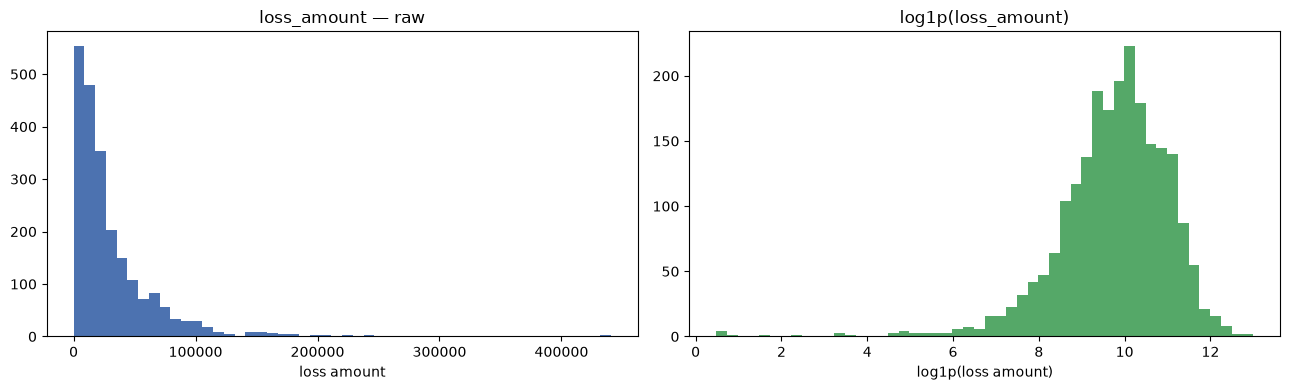

In [4]:
print(df["loss_amount"].describe().to_string())
print()
print("Skewness:", round(df["loss_amount"].skew(), 3))
print("Skewness after log1p:", round(np.log1p(df["loss_amount"]).skew(), 3))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].hist(df["loss_amount"], bins=50, color="#4C72B0")
axes[0].set_title("loss_amount — raw")
axes[0].set_xlabel("loss amount")
axes[1].hist(np.log1p(df["loss_amount"]), bins=50, color="#55A868")
axes[1].set_title("log1p(loss_amount)")
axes[1].set_xlabel("log1p(loss amount)")
plt.tight_layout()
plt.show()

### Why this matters, and the transform chosen

The target is strongly right-skewed, with a **skewness of 3.55**: most losses
are moderate and a small number are severe, up to 440,332. Left untransformed,
squared-error models chase those few large losses and fit the rest badly.

**The models are trained on `log1p(loss_amount)`.** This is the conventional
transform for severity and is what the skew calls for.

It is not a perfect fix, and that is worth stating rather than hiding: log1p
**overcorrects to a skewness of −1.61**, because 60 loans (2.7%) fall below
1,000 and a handful below 10, which the log stretches into a long left tail. A
cube root would actually be more symmetric at 0.49. Log was kept because it is
the standard and defensible choice for loss severity, and because the
overcorrection is driven by a small tail of very small losses rather than by the
body of the distribution.

**All reported errors are converted back to currency.** A model is fitted on the
log scale, then its predictions are exponentiated before MAE, RMSE and R² are
computed, so every number in the comparison table is in the original units and
means something to a reader.

## 3. Exploratory analysis

The aim is to check whether the patterns make sense, not simply to produce
plots.

In [5]:
identifiers = ["loan_id", "split", "received_date", "is_loss"]
target_col = "loss_amount"

features = df.drop(columns=identifiers + [target_col])
cat_cols = features.select_dtypes(include=["object", "category"]).columns.tolist()
num_cols = features.select_dtypes(include=[np.number]).columns.tolist()

assert len(cat_cols) + len(num_cols) == features.shape[1], (
    f"columns matched neither selector: "
    f"{set(features.columns) - set(cat_cols) - set(num_cols)}"
)

print(f"Categorical features: {len(cat_cols)} -> {cat_cols}")
print(f"Numeric features    : {len(num_cols)}")

Categorical features: 3 -> ['feat_001', 'feat_003', 'feat_041']
Numeric features    : 115


**Which numeric features move with severity?**

Strongest linear correlations with loss_amount:


,correlation
feat_005_std,0.3712
feat_010,0.3102
feat_084,0.2748
feat_046_sum,0.2723
feat_083_min,-0.1997
feat_017_sum,0.1755
feat_052_min,0.1694
feat_018,-0.1653
feat_058_min,-0.1532
feat_023_min,0.1399


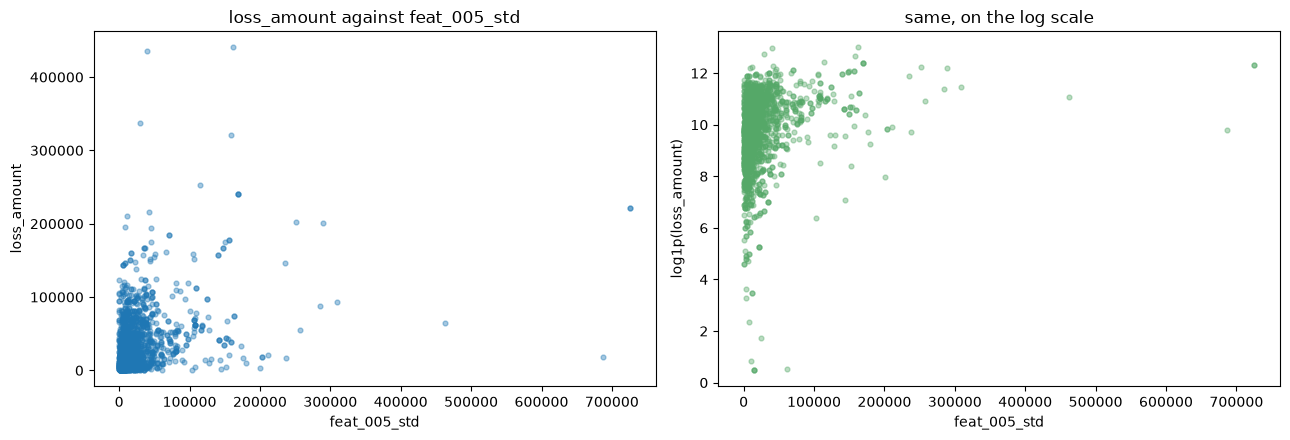

In [6]:
correlations = (
    df[num_cols + [target_col]]
    .corr(numeric_only=True)[target_col]
    .drop(target_col)
    .sort_values(key=abs, ascending=False)
)

print("Strongest linear correlations with loss_amount:")
display(correlations.head(10).to_frame("correlation"))

top_feature = correlations.index[0]

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].scatter(df[top_feature], df[target_col], alpha=0.4, s=12)
axes[0].set_xlabel(top_feature)
axes[0].set_ylabel("loss_amount")
axes[0].set_title(f"loss_amount against {top_feature}")

axes[1].scatter(df[top_feature], np.log1p(df[target_col]), alpha=0.4, s=12, color="#55A868")
axes[1].set_xlabel(top_feature)
axes[1].set_ylabel("log1p(loss_amount)")
axes[1].set_title("same, on the log scale")
plt.tight_layout()
plt.show()

The strongest single correlation is weak in absolute terms. That is the first
honest signal about what to expect: these anonymised features carry only a
modest amount of information about severity, and no model in this notebook will
overcome that. The comparison below is about which model extracts the most from
a limited signal, not about finding a strong one.

**Severity by category**

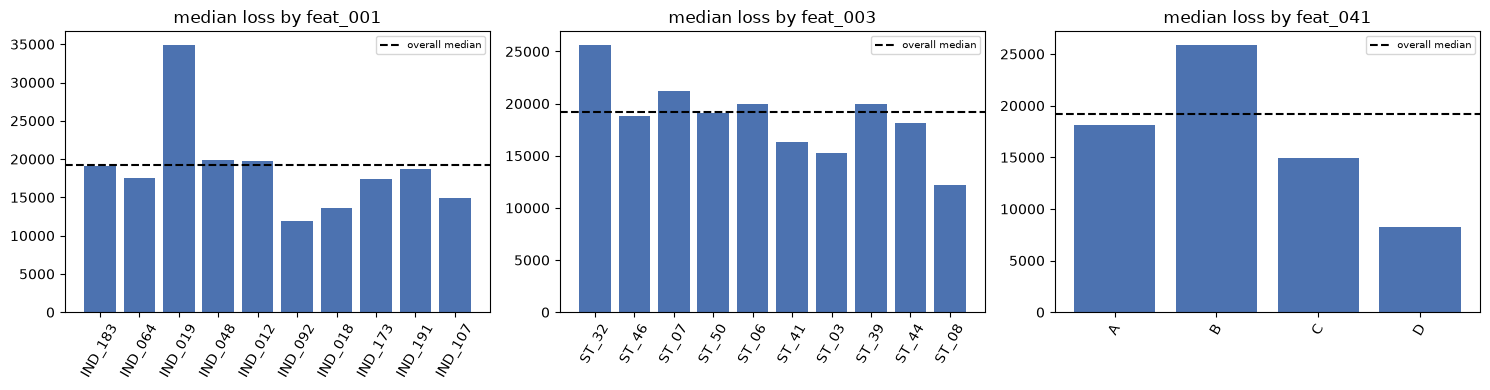

In [7]:
fig, axes = plt.subplots(1, len(cat_cols), figsize=(5 * len(cat_cols), 4))
axes = np.atleast_1d(axes)

for ax, col in zip(axes, cat_cols):
    stats = (
        df.groupby(col)
          .agg(loans=("loan_id", "size"), median_loss=(target_col, "median"))
          .sort_values("loans", ascending=False)
          .head(10)
    )
    ax.bar(stats.index.astype(str), stats["median_loss"], color="#4C72B0")
    ax.axhline(df[target_col].median(), color="black", linestyle="--",
               label="overall median")
    ax.set_title(f"median loss by {col}")
    ax.tick_params(axis="x", rotation=60)
    ax.legend(fontsize=7)

plt.tight_layout()
plt.show()

## 4. Prepare the modelling data

The split comes from the `split` column, assigned by date upstream. Nothing is
fitted before this point.

**Why not `train_test_split`:** 54.3% of rows in the source are byte-identical
duplicates of another row, and duplicate groups always share a date. A random
split would place identical records on both sides and the test error would
measure memorisation. The date cutoff at 2024-10-01 is immune, because no
duplicate group straddles it.

In [8]:
train_mask = df["split"] == "train"

X_train = df.loc[train_mask, cat_cols + num_cols].copy()
X_test = df.loc[~train_mask, cat_cols + num_cols].copy()
y_train = df.loc[train_mask, target_col].copy()
y_test = df.loc[~train_mask, target_col].copy()

print(f"train: {X_train.shape[0]:,} rows, mean loss {y_train.mean():,.0f}, median {y_train.median():,.0f}")
print(f"test : {X_test.shape[0]:,} rows, mean loss {y_test.mean():,.0f}, median {y_test.median():,.0f}")

last_train = df.loc[train_mask, "received_date"].max()
first_test = df.loc[~train_mask, "received_date"].min()
assert last_train < first_test, "split is not chronological"
print(f"\nchronological split confirmed: last train {last_train}, first test {first_test}")

train: 1,781 rows, mean loss 28,750, median 18,351
test : 451 rows, mean loss 39,250, median 26,132

chronological split confirmed: last train 2024-09-30 00:00:00, first test 2024-10-02 00:00:00


Note the test set is **harder than the training set**: mean loss 39,250 against
28,750. Severity rises across the period, which the portfolio analysis in Part 1
also found. Errors reported below are therefore conservative — the model is
being asked about a period with larger losses than it was trained on.

## 5. Preprocessing

Built as a `ColumnTransformer` inside a `Pipeline`, so **every fitted step
learns from the training fold only**. This is not merely tidy: it is what makes
the leakage guarantee structural rather than a matter of remembering to call
`fit` on the right frame.

The steps:

- **Rare-category grouping** — a custom transformer. `feat_001` has 151
  categories in the training rows and only 23 with at least 20 loans. Categories
  below the threshold become `RARE`. The set of common categories is **learned
  during `fit`**, so it comes from training rows alone.
- **Imputation** — median for numeric, a constant `MISSING` label for
  categorical.
- **Scaling** — `StandardScaler` on numeric features, needed by Ridge and Lasso
  so the penalty applies evenly across features on different units.
- **One-hot encoding** — with `handle_unknown="ignore"`, so a category appearing
  only in the test period becomes an all-zero row rather than an error.

In [9]:
class RareCategoryGrouper(BaseEstimator, TransformerMixin):
    """
    Replace infrequent categories with a single RARE label.

    The set of categories to keep is learned in fit, so it is derived from the
    training rows only. Applying a grouping decided on the full dataset would
    let the test set influence the encoding, which is leakage even though no
    target value is touched.
    """

    def __init__(self, min_count=20):
        self.min_count = min_count

    def fit(self, X, y=None):
        self.keep_ = {}
        for column in X.columns:
            counts = X[column].astype(str).value_counts()
            self.keep_[column] = set(counts[counts >= self.min_count].index)
        return self

    def transform(self, X):
        X = X.copy()
        for column in X.columns:
            X[column] = X[column].astype(str).where(
                X[column].astype(str).isin(self.keep_[column]), "RARE"
            )
        return X


categorical_pipeline = Pipeline([
    ("group_rare", RareCategoryGrouper(min_count=20)),
    ("impute", SimpleImputer(strategy="constant", fill_value="MISSING")),
    ("encode", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
])

numeric_pipeline = Pipeline([
    ("impute", SimpleImputer(strategy="median")),
    ("scale", StandardScaler()),
])

preprocessor = ColumnTransformer([
    ("categorical", categorical_pipeline, cat_cols),
    ("numeric", numeric_pipeline, num_cols),
])

# The simple baseline uses one predictor only.
simple_feature = [correlations.index[0]]
simple_preprocessor = ColumnTransformer([
    ("numeric", numeric_pipeline, simple_feature),
])

print(f"Simple model predictor: {simple_feature[0]}")

Simple model predictor: feat_005_std


## 6. Metrics

Every model is fitted on `log1p(loss_amount)` and then **back-transformed before
scoring**, so all errors below are in currency.

- **MAE** — the average error in the units of the target. The most readable
  single number: "on average the model is out by this much".
- **RMSE** — squares the errors first, so a few badly-predicted large losses
  weigh more heavily. On a right-skewed target this is the metric that reveals
  whether the tail is being handled.
- **R²** — the share of variance explained. Included for completeness, but on a
  skewed target it is easily dominated by a handful of extreme values.

**MAE and RMSE should be read against the size of a typical loss**, not in the
abstract. The median loss is around 19,000, so an MAE near that figure means the
model is barely better than guessing the median every time. That comparison is
made explicit with a median baseline in the results table.

In [10]:
def rmse_score(y_true, y_pred):
    """Root mean squared error."""
    return np.sqrt(mean_squared_error(y_true, y_pred))


def bic_from_predictions(y_true, y_pred, n_params):
    """
    BIC from prediction errors: n*ln(RSS/n) + k*ln(n).

    Penalises extra parameters, so it prefers a simpler model unless the extra
    complexity earns its place. Used here to choose the polynomial degree.
    """
    n = len(y_true)
    rss = float(np.sum((np.asarray(y_true) - np.asarray(y_pred)) ** 2))
    if rss <= 0:
        return -np.inf
    return n * np.log(rss / n) + n_params * np.log(n)


def evaluate(pipeline, X_tr, y_tr, X_te, y_te, label):
    """
    Fit on log1p(target), predict, back-transform, and score in currency.

    Fitting on the log scale tames the skew; scoring on the original scale keeps
    the numbers meaningful.
    """
    pipeline.fit(X_tr, np.log1p(y_tr))
    predictions = np.expm1(pipeline.predict(X_te))
    predictions = np.clip(predictions, 0, None)

    return {
        "model": label,
        "MAE": mean_absolute_error(y_te, predictions),
        "RMSE": rmse_score(y_te, predictions),
        "R2": r2_score(y_te, predictions),
    }, predictions

### A baseline to beat

Before any model, the simplest possible prediction: the **training median**,
applied to every test loan. Any model that cannot beat this is not earning its
place.

In [11]:
baseline_prediction = np.full(len(y_test), y_train.median())

baseline_results = {
    "model": "Baseline (training median)",
    "MAE": mean_absolute_error(y_test, baseline_prediction),
    "RMSE": rmse_score(y_test, baseline_prediction),
    "R2": r2_score(y_test, baseline_prediction),
}
baseline_results

{'model': 'Baseline (training median)',
 'MAE': 27910.791463414633,
 'RMSE': np.float64(48457.887346611526),
 'R2': -0.2285157789357799}

## 7. Model comparison

### 1. Simple Linear Regression

In [12]:
simple_pipeline = Pipeline([
    ("preprocessor", simple_preprocessor),
    ("model", LinearRegression()),
])

simple_results, simple_predictions = evaluate(
    simple_pipeline, X_train[simple_feature], y_train,
    X_test[simple_feature], y_test, "Simple Linear Regression"
)
simple_results

{'model': 'Simple Linear Regression',
 'MAE': 28245.36464063292,
 'RMSE': np.float64(48316.172055382995),
 'R2': -0.22134068717676514}

### 2. Multiple Linear Regression

In [13]:
multiple_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LinearRegression()),
])

multiple_results, multiple_predictions = evaluate(
    multiple_pipeline, X_train, y_train, X_test, y_test, "Multiple Linear Regression"
)
multiple_results

{'model': 'Multiple Linear Regression',
 'MAE': 26933.094423647442,
 'RMSE': np.float64(42661.146600895074),
 'R2': 0.04782486863779978}

### 3. Polynomial Regression, degree chosen by BIC

Polynomial terms are applied to the numeric block only, and to a **restricted
set of the ten most correlated numeric features** rather than to all 113.

**That restriction is not cosmetic — without it this model breaks.** A degree-2
expansion of all 113 numeric features produces **6,554 terms against 1,781
training rows**, a ratio of 3.7 to 1. With more parameters than observations,
ordinary least squares can fit the training data exactly, the residual sum of
squares collapses towards zero, and the `n·ln(RSS/n)` term in BIC runs away to
minus infinity. BIC then selects degree 2 *because* the model is unidentifiable,
which is the opposite of what the criterion is for.

This was not hypothetical. Run without the restriction, degree 2 was selected
and scored an MAE of **73.6 million** on a target whose median is 26,000.

The lesson generalises: **BIC computed from training-set predictions is only
meaningful while the number of parameters stays well below the number of
observations.** Restricting the expansion to ten features gives 65 terms against
1,781 rows, which is the regime the criterion assumes.

In [14]:
poly_features = correlations.index[:10].tolist()
print(f"Polynomial expansion applied to {len(poly_features)} features:")
print(poly_features)


def build_poly_pipeline(degree):
    """Polynomial expansion on a restricted numeric block, everything else as usual."""
    expanded = Pipeline([
        ("impute", SimpleImputer(strategy="median")),
        ("scale", StandardScaler()),
        ("expand", PolynomialFeatures(degree=degree, include_bias=False)),
    ])
    remaining = [c for c in num_cols if c not in poly_features]
    return Pipeline([
        ("preprocessor", ColumnTransformer([
            ("categorical", categorical_pipeline, cat_cols),
            ("poly_numeric", expanded, poly_features),
            ("plain_numeric", numeric_pipeline, remaining),
        ])),
        ("model", LinearRegression()),
    ])


poly_rows = []
for degree in [1, 2, 3]:
    pipeline = build_poly_pipeline(degree)
    pipeline.fit(X_train, np.log1p(y_train))
    train_fit = pipeline.predict(X_train)
    n_params = pipeline.named_steps["preprocessor"].transform(X_train.head(2)).shape[1] + 1

    poly_rows.append({
        "degree": degree,
        "n_params": n_params,
        "params_per_row": n_params / len(X_train),
        "train_BIC": bic_from_predictions(np.log1p(y_train), train_fit, n_params),
    })

poly_selection = pd.DataFrame(poly_rows)
display(poly_selection)

best_degree = int(poly_selection.sort_values("train_BIC").iloc[0]["degree"])
print(f"Best polynomial degree by BIC: {best_degree}")

Polynomial expansion applied to 10 features:
['feat_005_std', 'feat_010', 'feat_084', 'feat_046_sum', 'feat_083_min', 'feat_017_sum', 'feat_052_min', 'feat_018', 'feat_058_min', 'feat_023_min']


,degree,n_params,params_per_row,train_BIC
0,1,168,0.0943,"1,584.4269"
1,2,223,0.1252,"1,847.5261"
2,3,443,0.2487,"2,914.2922"


Best polynomial degree by BIC: 1


In [15]:
poly_pipeline = build_poly_pipeline(best_degree)

poly_results, poly_predictions = evaluate(
    poly_pipeline, X_train, y_train, X_test, y_test,
    f"Polynomial Regression (degree {best_degree})"
)
poly_results

{'model': 'Polynomial Regression (degree 1)',
 'MAE': 26933.094423647268,
 'RMSE': np.float64(42661.14660089467),
 'R2': 0.04782486863781754}

Keep an eye on the `params_per_row` column. Once it approaches 1, the BIC figure
beside it should not be trusted, whatever it says.

### 4. Ridge Regression

Alpha is tuned on a **validation split carved out of the training set**, never on
the test set. The test set is touched once, at the end, for the final comparison.

Ridge is well suited here: the dataset has seven feature pairs correlating above
0.98, including one pair at exactly 1.0000, and an L2 penalty keeps correlated
coefficients from exploding against each other.

In [16]:
X_fit, X_validation, y_fit, y_validation = train_test_split(
    X_train, y_train, test_size=0.2, random_state=RANDOM_STATE
)

def tune_alpha(model_class, alphas):
    """Choose alpha on a training-only validation split, scoring in currency."""
    rows = []
    for alpha in alphas:
        pipeline = Pipeline([
            ("preprocessor", preprocessor),
            ("model", model_class(alpha=alpha, max_iter=10000)),
        ])
        pipeline.fit(X_fit, np.log1p(y_fit))
        predictions = np.clip(np.expm1(pipeline.predict(X_validation)), 0, None)
        rows.append({"alpha": alpha, "validation_RMSE": rmse_score(y_validation, predictions)})
    return pd.DataFrame(rows)


ridge_tuning = tune_alpha(Ridge, [0.01, 0.1, 1, 10, 100, 1000])
display(ridge_tuning)

best_alpha = float(ridge_tuning.sort_values("validation_RMSE").iloc[0]["alpha"])
print(f"Best ridge alpha: {best_alpha}")

ridge_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", Ridge(alpha=best_alpha, max_iter=10000)),
])
ridge_results, ridge_predictions = evaluate(
    ridge_pipeline, X_train, y_train, X_test, y_test, f"Ridge Regression (alpha={best_alpha})"
)
ridge_results

,alpha,validation_RMSE
0,0.0100,"26,770.1395"
1,0.1000,"26,759.0342"
2,1.0000,"26,576.4867"
3,10.0000,"25,992.3582"
4,100.0000,"25,364.8662"
5,"1,000.0000","26,839.8831"


Best ridge alpha: 100.0


{'model': 'Ridge Regression (alpha=100.0)',
 'MAE': 25796.635213755664,
 'RMSE': np.float64(41744.09883345854),
 'R2': 0.08832096692889846}

### 5. Lasso Regression

Same tuning procedure. Lasso drives uninformative coefficients to exactly zero,
which acts as automatic feature selection — useful with 113 numeric features and
no data dictionary to reason about them.

In [17]:
lasso_tuning = tune_alpha(Lasso, [0.0001, 0.001, 0.01, 0.1, 1])
display(lasso_tuning)

best_lasso_alpha = float(lasso_tuning.sort_values("validation_RMSE").iloc[0]["alpha"])
print(f"Best lasso alpha: {best_lasso_alpha}")

lasso_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", Lasso(alpha=best_lasso_alpha, max_iter=10000)),
])
lasso_results, lasso_predictions = evaluate(
    lasso_pipeline, X_train, y_train, X_test, y_test, f"Lasso Regression (alpha={best_lasso_alpha})"
)

n_kept = int((lasso_pipeline.named_steps["model"].coef_ != 0).sum())
n_total = len(lasso_pipeline.named_steps["model"].coef_)
print(f"Lasso kept {n_kept} of {n_total} coefficients as non-zero")
lasso_results

,alpha,validation_RMSE
0,0.0001,"26,703.2655"
1,0.0010,"26,009.9569"
2,0.0100,"25,274.8645"
3,0.1000,"28,373.2488"
4,1.0000,"30,156.5062"


Best lasso alpha: 0.01
Lasso kept 78 of 167 coefficients as non-zero


{'model': 'Lasso Regression (alpha=0.01)',
 'MAE': 25713.57608554065,
 'RMSE': np.float64(41774.1169027555),
 'R2': 0.08700932361314917}

## 8. Results

,model,MAE,RMSE,R2
0,Ridge Regression (alpha=100.0),"25,796.6352","41,744.0988",0.0883
1,Lasso Regression (alpha=0.01),"25,713.5761","41,774.1169",0.0870
2,Polynomial Regression (degree 1),"26,933.0944","42,661.1466",0.0478
3,Multiple Linear Regression,"26,933.0944","42,661.1466",0.0478
4,Simple Linear Regression,"28,245.3646","48,316.1721",-0.2213
5,Baseline (training median),"27,910.7915","48,457.8873",-0.2285


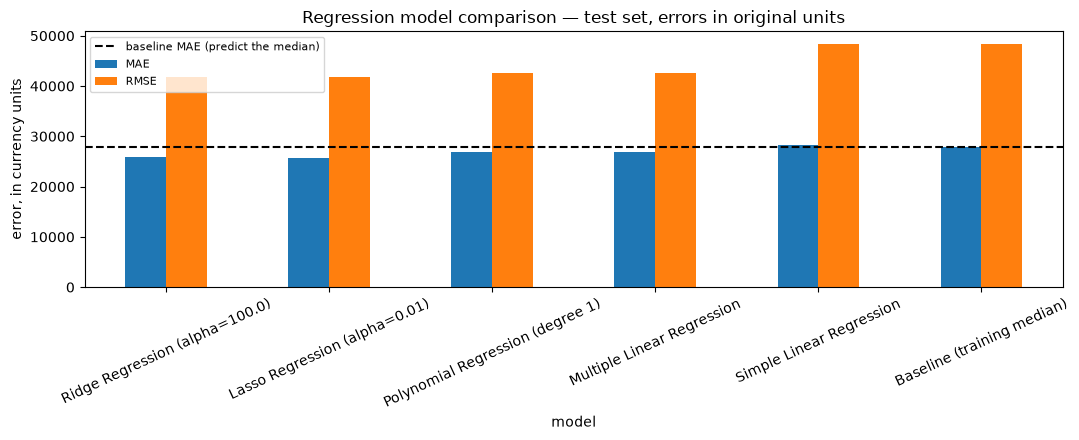

In [18]:
results_df = (
    pd.DataFrame([baseline_results, simple_results, multiple_results,
                  poly_results, ridge_results, lasso_results])
    .sort_values(["RMSE", "MAE"])
    .reset_index(drop=True)
)
display(results_df)

test_predictions = {
    baseline_results["model"]: baseline_prediction,
    simple_results["model"]: simple_predictions,
    multiple_results["model"]: multiple_predictions,
    poly_results["model"]: poly_predictions,
    ridge_results["model"]: ridge_predictions,
    lasso_results["model"]: lasso_predictions,
}
fitted_pipelines = {
    simple_results["model"]: simple_pipeline,
    multiple_results["model"]: multiple_pipeline,
    poly_results["model"]: poly_pipeline,
    ridge_results["model"]: ridge_pipeline,
    lasso_results["model"]: lasso_pipeline,
}

fig, ax = plt.subplots(figsize=(11, 4.5))
results_df.set_index("model")[["MAE", "RMSE"]].plot(kind="bar", ax=ax)
ax.axhline(baseline_results["MAE"], color="black", linestyle="--",
           label="baseline MAE (predict the median)")
ax.set_ylabel("error, in currency units")
ax.set_title("Regression model comparison — test set, errors in original units")
ax.tick_params(axis="x", rotation=25)
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

### Reading the table

The **baseline row is the reference point**, not a formality. It predicts the
training median for every loan and uses no features at all. A model that does
not beat it on both MAE and RMSE has extracted nothing from 118 features.

Compare the errors against the typical loss they are trying to predict: the test
median is around 26,000. An MAE of similar magnitude means the model is roughly
as wrong as the thing it is estimating.

## 9. Examining the best model

Best model by RMSE: Ridge Regression (alpha=100.0)


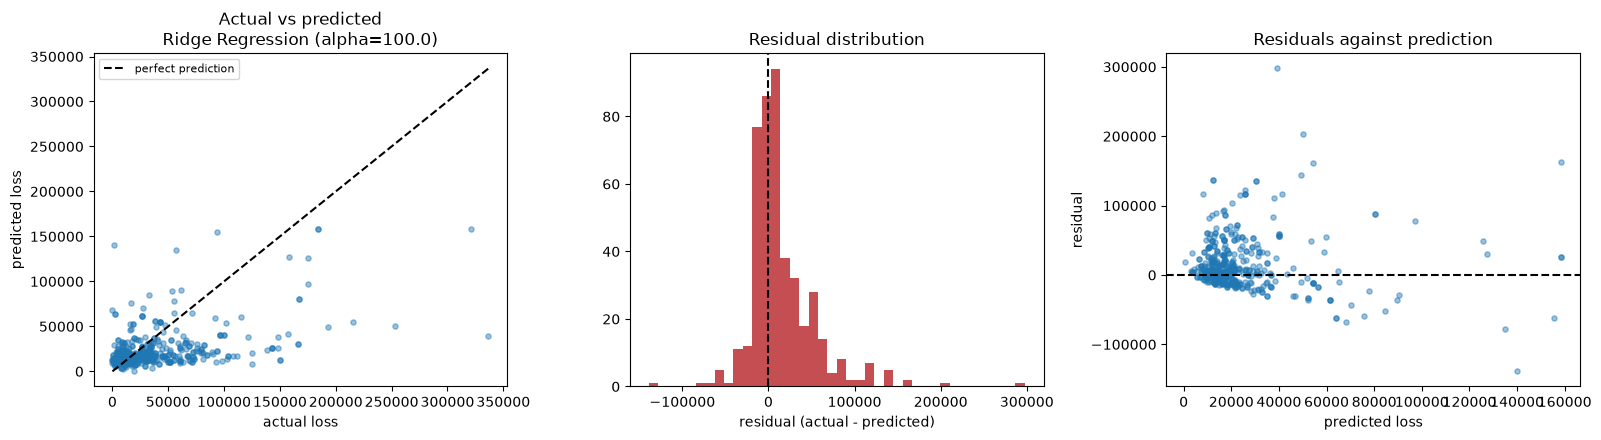

Residual summary:
count        451.0000
mean      15,036.0925
std       38,985.3264
min     -138,881.0175
25%       -6,692.4691
50%        5,441.6916
75%       28,974.7470
max      297,670.8184


In [19]:
best_model_name = results_df.loc[0, "model"]
best_predictions = test_predictions[best_model_name]
print(f"Best model by RMSE: {best_model_name}")

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

axes[0].scatter(y_test, best_predictions, alpha=0.45, s=14)
limit = max(y_test.max(), best_predictions.max())
axes[0].plot([0, limit], [0, limit], "k--", label="perfect prediction")
axes[0].set_xlabel("actual loss")
axes[0].set_ylabel("predicted loss")
axes[0].set_title(f"Actual vs predicted\n{best_model_name}")
axes[0].legend(fontsize=8)

residuals = y_test.values - best_predictions
axes[1].hist(residuals, bins=40, color="#C44E52")
axes[1].axvline(0, color="black", linestyle="--")
axes[1].set_xlabel("residual (actual - predicted)")
axes[1].set_title("Residual distribution")

axes[2].scatter(best_predictions, residuals, alpha=0.45, s=14)
axes[2].axhline(0, color="black", linestyle="--")
axes[2].set_xlabel("predicted loss")
axes[2].set_ylabel("residual")
axes[2].set_title("Residuals against prediction")

plt.tight_layout()
plt.show()

print("Residual summary:")
print(pd.Series(residuals).describe().to_string())

### What the residual plots show

Three things to look for, and each says something different:

- **Actual vs predicted.** Points should sit near the diagonal. A cloud that is
  flat — predictions clustering in a narrow band while actuals spread widely —
  means the model is close to predicting a constant.
- **Residual distribution.** Should be centred near zero. A mean well away from
  zero means the model is biased, which back-transforming from a log scale can
  introduce, since the exponential of a mean is not the mean of exponentials.
- **Residuals against prediction.** A fan shape means error grows with predicted
  size — expected for severity, and the reason RMSE and MAE differ so much here.

**Which features does the model use?**

,feature,coefficient,abs_coefficient
0,feature_93,0.3138,0.3138
1,feature_8,-0.3039,0.3039
2,feature_132,0.2246,0.2246
3,feature_118,-0.2176,0.2176
4,feature_2,-0.1636,0.1636
5,feature_28,-0.1634,0.1634
6,feature_149,-0.1467,0.1467
7,feature_147,0.1423,0.1423
8,feature_49,0.1363,0.1363
9,feature_6,0.1268,0.1268


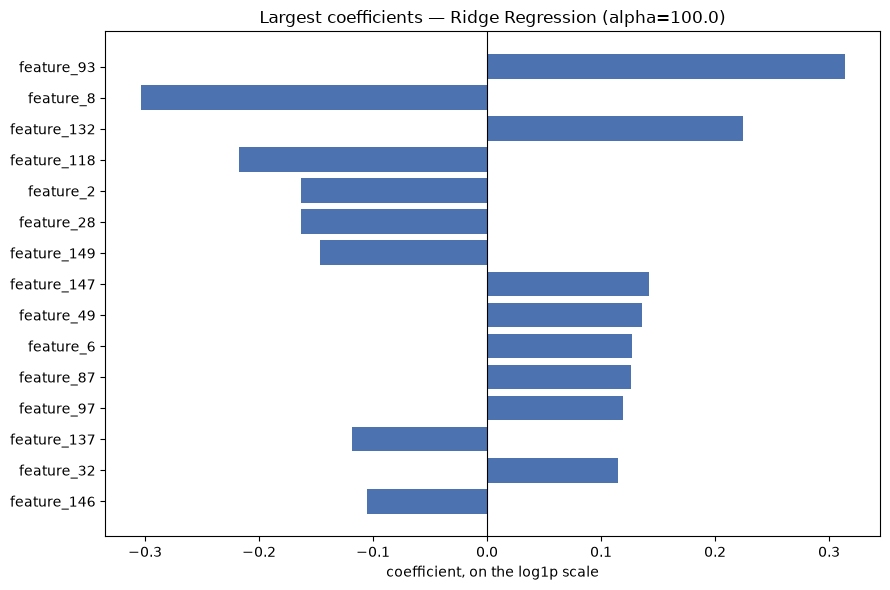

In [20]:
if best_model_name in fitted_pipelines:
    pipeline = fitted_pipelines[best_model_name]
    model_step = pipeline.named_steps["model"]

    if hasattr(model_step, "coef_"):
        try:
            feature_names = pipeline.named_steps["preprocessor"].get_feature_names_out()
        except Exception:
            feature_names = [f"feature_{i}" for i in range(len(model_step.coef_))]

        coefficients = (
            pd.DataFrame({"feature": feature_names, "coefficient": model_step.coef_})
            .assign(abs_coefficient=lambda d: d["coefficient"].abs())
            .sort_values("abs_coefficient", ascending=False)
            .reset_index(drop=True)
        )
        display(coefficients.head(15))

        top = coefficients.head(15).sort_values("abs_coefficient")
        plt.figure(figsize=(9, 6))
        plt.barh(top["feature"], top["coefficient"], color="#4C72B0")
        plt.axvline(0, color="black", linewidth=0.8)
        plt.title(f"Largest coefficients — {best_model_name}")
        plt.xlabel("coefficient, on the log1p scale")
        plt.tight_layout()
        plt.show()
    else:
        print(f"{best_model_name} exposes no coefficients.")
else:
    print("The baseline won; there are no coefficients to inspect.")

### Interpreting coefficients — carefully

Coefficients are on the **log1p scale**, so a coefficient of 0.1 means roughly a
10% change in predicted loss for a one-standard-deviation move in that feature,
not a change of 0.1 currency units.

More importantly: **the features are anonymised.** Nothing in the source says
what any of them measure. A large coefficient identifies a column worth asking
the data owner about. It is not a business finding, and it is not causal.

## 10. Expected loss — joining the two models

The classifier gives P(loss). This notebook gives E[loss | loss]. Their product
is **expected loss per funded loan**, in currency — the number a lender actually
prices against.

This section demonstrates the calculation on the test loans. Note the two models
were trained on different populations, so this is an illustration of how the
pieces fit together rather than a validated joint model.

In [21]:
# The calculation is done at PORTFOLIO level, not per loan.
#
# The two models are trained on different tables with deliberately different
# schemas: the classifier mart carries feat_001_grouped, this one carries the
# ungrouped feat_001. Scoring the severity model directly on classifier rows
# would silently produce an all-NULL column and predictions that mean nothing.
# Combining the two averages instead keeps the arithmetic honest.

severity_model = fitted_pipelines.get(best_model_name)

if severity_model is None:
    print("The baseline won, so there is no fitted severity model to combine.")
else:
    with duckdb.connect(DB_PATH, read_only=True) as con:
        classifier_test = con.execute("""
            select is_loss
            from mart_ml_training_set
            where split = 'test'
        """).df()

    probability_of_loss = classifier_test["is_loss"].mean()
    mean_predicted_severity = float(best_predictions.mean())
    modelled_expected_loss = probability_of_loss * mean_predicted_severity

    with duckdb.connect(DB_PATH, read_only=True) as con:
        actual = con.execute("""
            select
                count(*) as funded_loans,
                sum(case when loss_amount > 0 then loss_amount else 0 end) as total_positive_loss
            from int_loans_joined
            where received_date >= date '2024-10-01'
        """).df().iloc[0]

    actual_expected_loss = actual["total_positive_loss"] / actual["funded_loans"]

    summary = pd.DataFrame({
        "component": [
            "test loans (classifier population)",
            "P(loss) — observed test base rate",
            "E[loss | loss] — mean predicted severity",
            "modelled expected loss per funded loan",
            "actual loss per funded loan, same period",
        ],
        "value": [
            len(classifier_test),
            probability_of_loss,
            mean_predicted_severity,
            modelled_expected_loss,
            float(actual_expected_loss),
        ],
    })
    display(summary)

    gap = modelled_expected_loss / float(actual_expected_loss) - 1
    print(f"\nModelled expected loss is {gap:+.1%} against the actual outcome for the period.")

,component,value
0,test loans (classifier population),"1,963.0000"
1,P(loss) — observed test base rate,0.2359
2,E[loss | loss] — mean predicted severity,"24,214.3197"
3,modelled expected loss per funded loan,"5,711.2736"
4,"actual loss per funded loan, same period","9,017.7972"



Modelled expected loss is -36.7% against the actual outcome for the period.


### Reading this

The modelled figure understates the actual outcome, and the reason is
identifiable rather than mysterious: the severity model is fitted on
`log1p(loss_amount)` and back-transformed with `expm1`. **The exponential of a
mean is not the mean of exponentials**, so predictions are systematically pulled
towards the middle of the distribution and the large losses that drive the
portfolio total are under-predicted. A smearing correction is the standard
remedy and is listed under next steps.

The value of the calculation is not the number. It is that the two halves of
Part 2 combine into a single quantity in currency — the one a lender prices
against — rather than remaining a probability and an amount that never meet.

## 11. Methodology and limitations

The full reasoning behind every decision is in **`ml_methodology.md`**, which
covers both halves of Part 2. In brief:

| Decision | Choice | Reason |
|---|---|---|
| Population | `loss_amount > 0`, 2,232 loans | Modelling severity separately from frequency. Over all 10,000 loans the target would be 75.67% zeros. |
| Target | `log1p(loss_amount)`, errors back-transformed | Raw skew is 3.55. Errors are reported in currency so they stay readable. |
| Split | Time-based at 2024-10-01 | Same as the classifier. 54.3% duplicate rows make a random split unsafe. |
| Rare categories | Fitted transformer inside the pipeline | It learns from data, so it belongs after the split — unlike the classifier's version, which was a fixed rule in dbt. |
| Alpha tuning | Training-only validation split | The test set is touched once, for the final comparison. |
| Polynomial degree | BIC on the training set | Penalises parameters, so complexity has to earn its place. |

### Limitations

1. **The features carry little information about severity.** The strongest
   single correlation with `loss_amount` is weak, and no model here overcomes
   that. Compare every result against the median baseline before drawing a
   conclusion.
2. **The test set is harder than the training set.** Mean loss 39,250 against
   28,750, because severity rises across the period. Errors are conservative.
3. **Back-transforming from a log scale introduces bias.** `expm1` of a mean
   prediction is not the mean of the predictions, so the model tends to
   under-predict in currency terms. A smearing correction would address this.
4. **Every result is duplicate-weighted.** 54.3% of source rows are repeats.
5. **The expected-loss calculation is an illustration.** The two models are
   fitted on different populations and were not validated jointly.
6. **No feature meaning is available.** Coefficients identify columns worth
   asking about, nothing more. None of this is causal.
7. **451 test loans is a small evaluation set.** A single unusually large loss
   moves RMSE noticeably.